In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
df = pd.read_csv('toptex.csv')
df.sample(3)

,Cust_ID,Gender_F_Flag,Gender_M_Flag,Residence_distance_from_store,time_in_store,accompanying_people,family_size,total_purchase_amount
2308,2309,1,0,2,51,3,5,1284
3025,3026,0,1,4,38,4,4,1510
3181,3182,1,0,5,51,1,4,1987


In [34]:
df.set_index('Cust_ID', inplace=True)

In [35]:
df.describe()

,Gender_F_Flag,Gender_M_Flag,Residence_distance_from_store,time_in_store,accompanying_people,family_size,total_purchase_amount
count,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000,4380.000000
mean,0.702511,0.297489,5.003425,47.952740,3.019635,4.034475,1580.639498
std,0.457205,0.457205,2.226137,6.982038,1.721425,1.043668,439.721994
min,0.000000,0.000000,0.000000,34.000000,0.000000,1.000000,113.000000
25%,0.000000,0.000000,3.000000,39.000000,2.000000,3.000000,1274.750000
50%,1.000000,0.000000,5.000000,52.000000,3.000000,4.000000,1566.000000
75%,1.000000,1.000000,6.000000,53.000000,4.000000,5.000000,1874.000000
max,1.000000,1.000000,16.000000,57.000000,11.000000,8.000000,3259.000000


In [28]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Drop rows with missing values
df_cleaned = df.dropna()
print("\nDataframe after dropping rows with missing values:")
print(df_cleaned.info())

Missing values in each column:
 Cust_ID                          0
Gender_F_Flag                    0
Gender_M_Flag                    0
Residence_distance_from_store    0
time_in_store                    0
accompanying_people              0
family_size                      0
total_purchase_amount            0
dtype: int64

Dataframe after dropping rows with missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Cust_ID                        4380 non-null   int64
 1   Gender_F_Flag                  4380 non-null   int64
 2   Gender_M_Flag                  4380 non-null   int64
 3   Residence_distance_from_store  4380 non-null   int64
 4   time_in_store                  4380 non-null   int64
 5   accompanying_people            4380 non-null   int64
 6   family_size                    4380 non-null   i

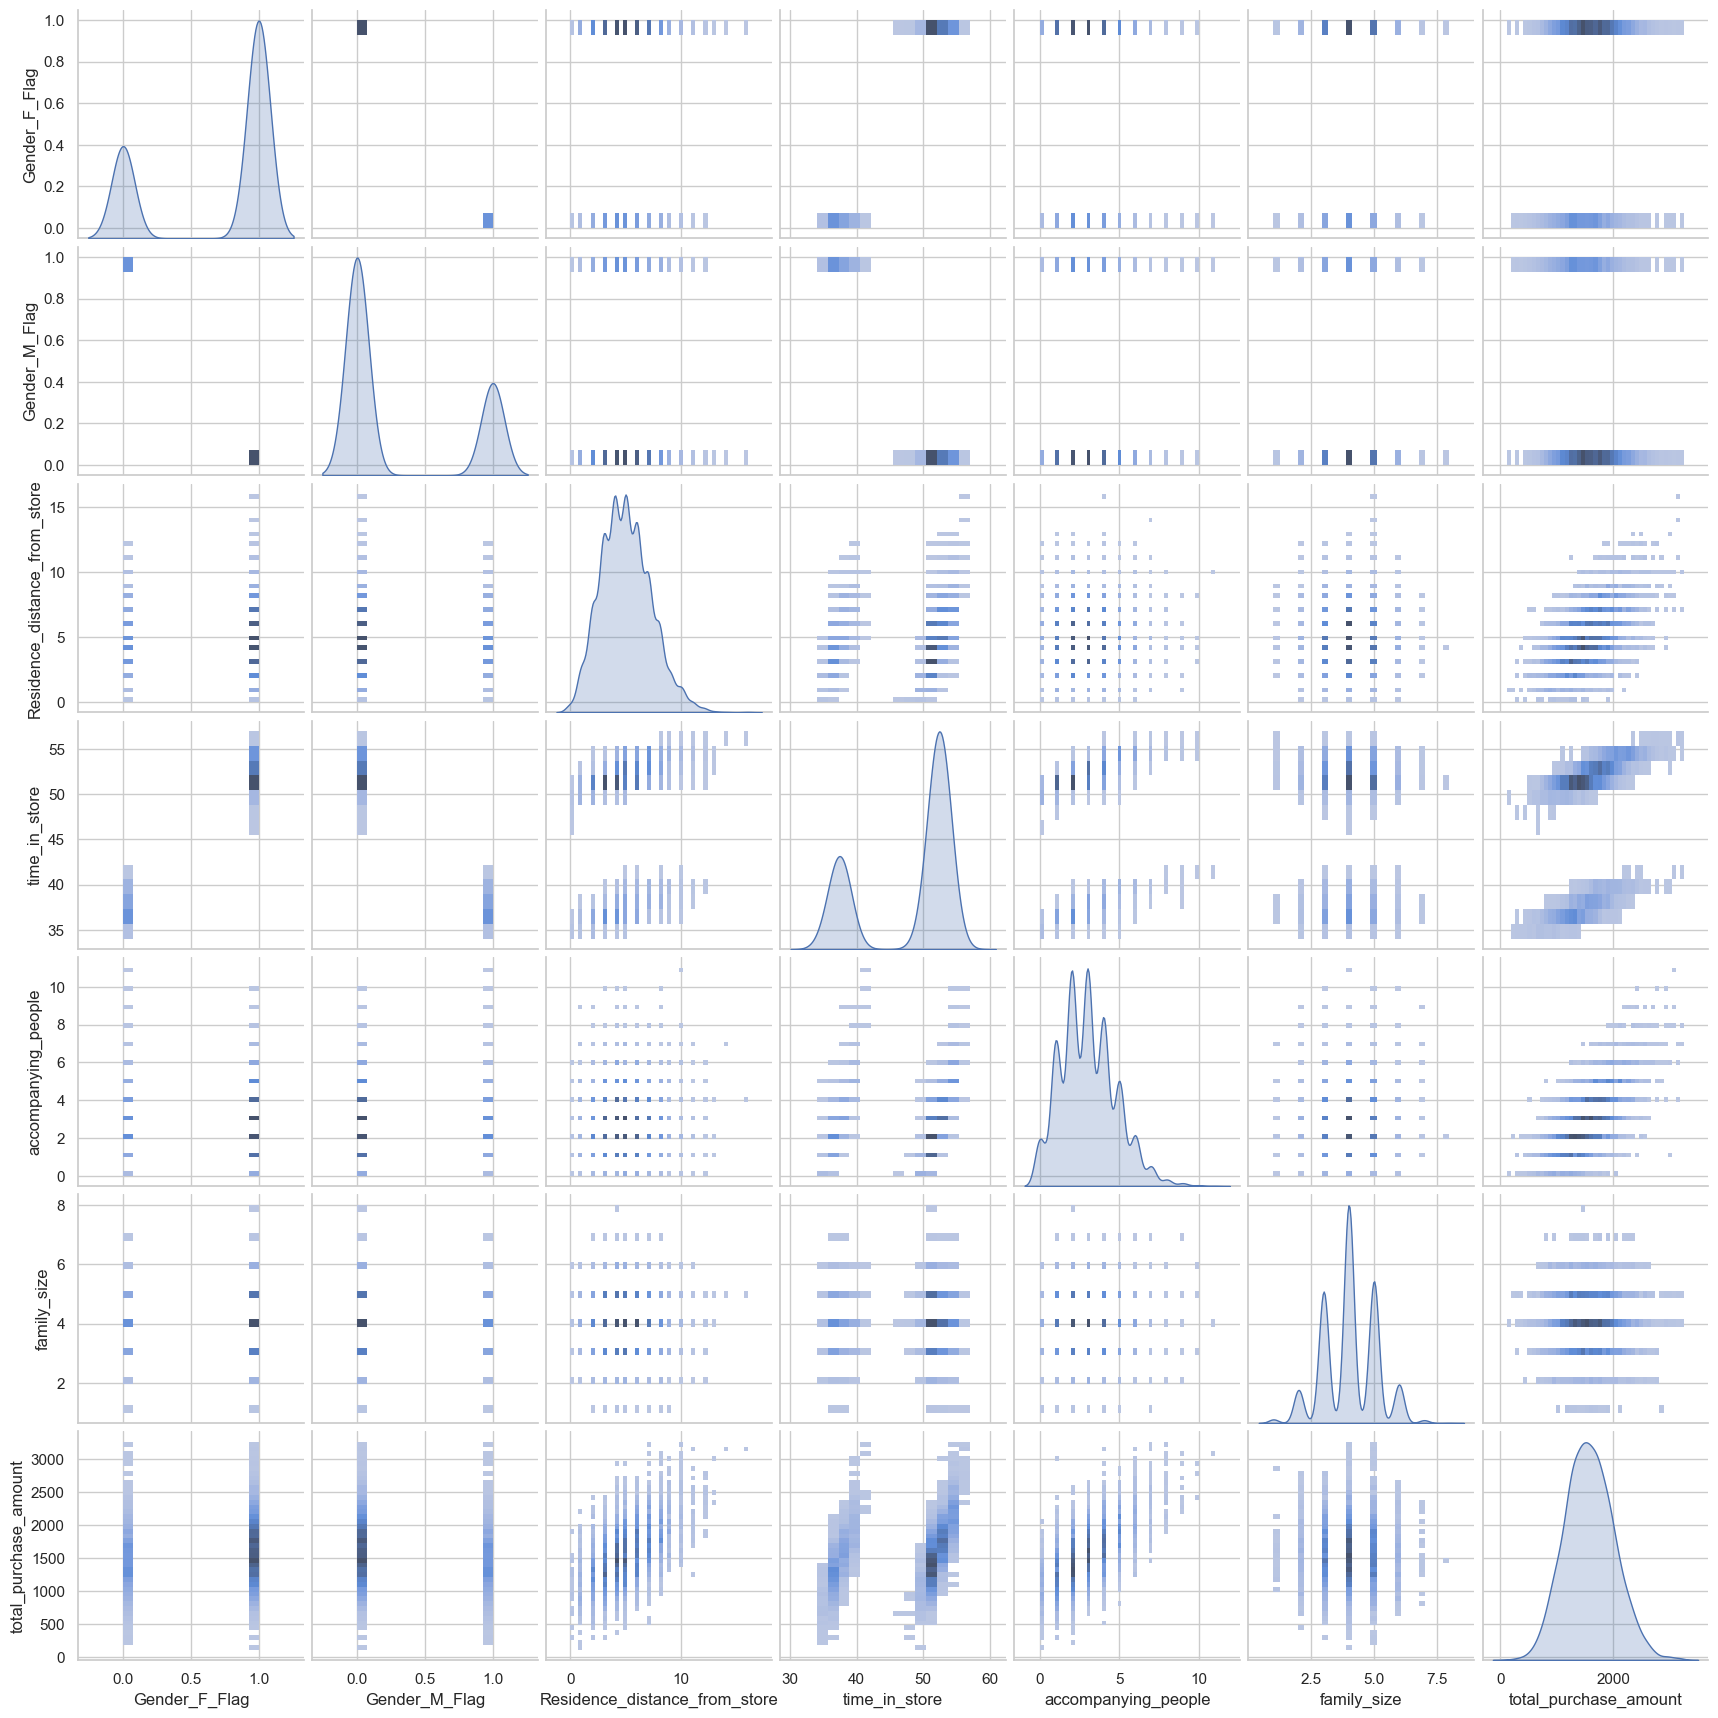

In [46]:
import seaborn as sns
sns.pairplot(df, diag_kind='kde',kind='hist')


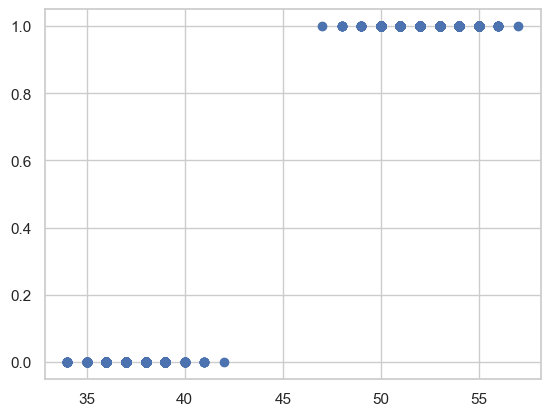

In [21]:
plt.scatter(df['time_in_store'],df['Gender_F_Flag'])

<Axes: >

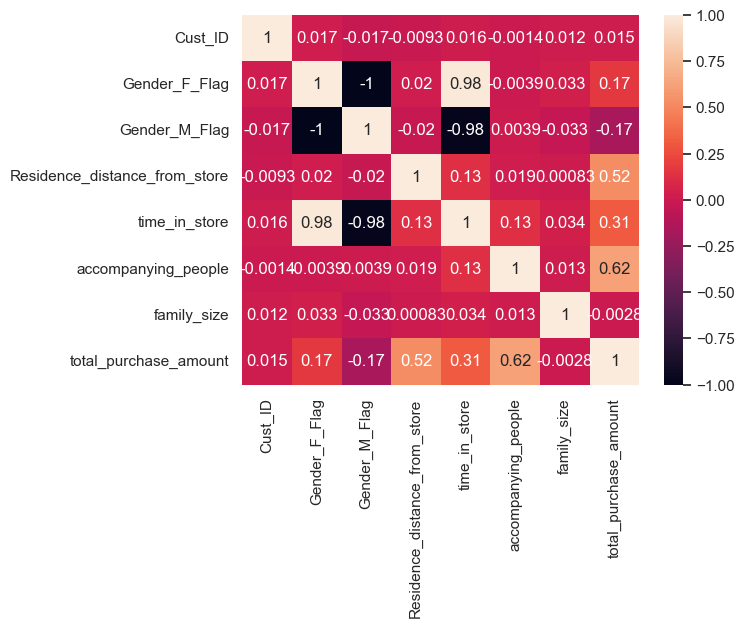

In [16]:
sns.heatmap(df.corr(), annot=True)

Model: LinearRegression
Mean Squared Error: 62472.38525107833
R^2 Score: 0.6766391553883062
------------------------------


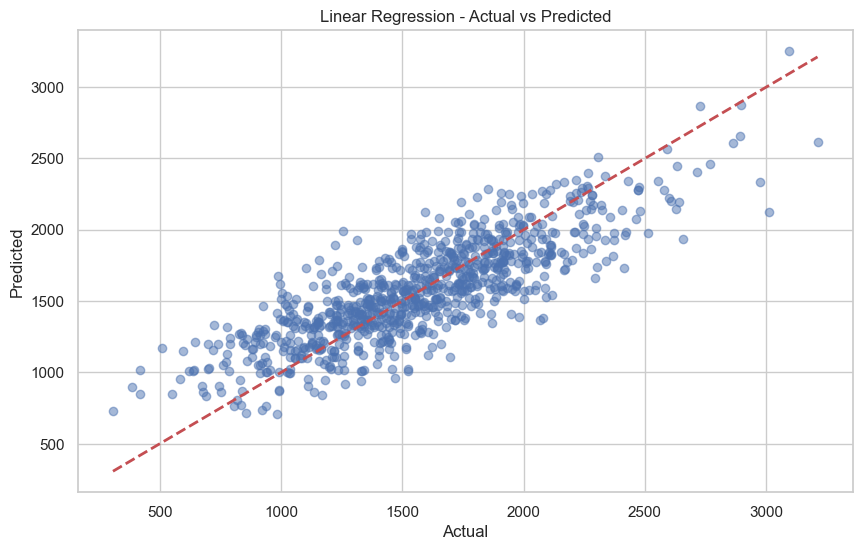

Model: RandomForestRegressor
Mean Squared Error: 80757.38896347031
R^2 Score: 0.5819948702308899
------------------------------


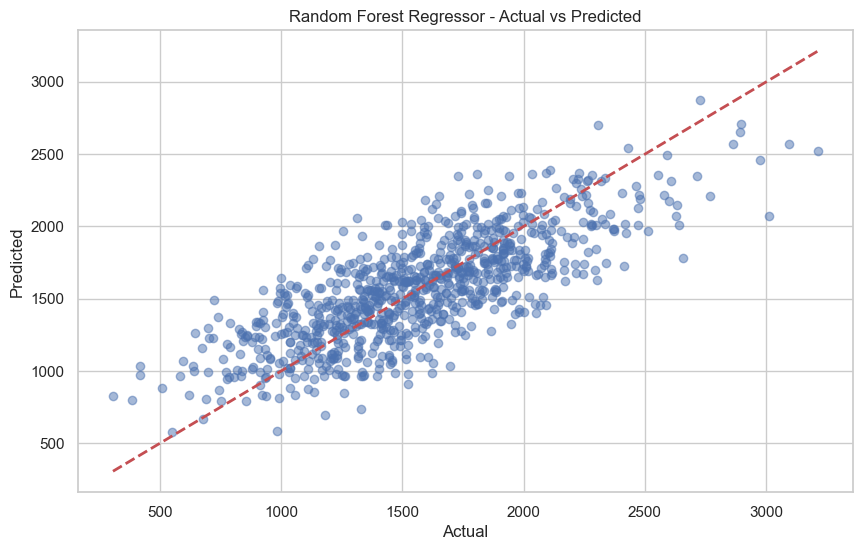

Model: SVR
Mean Squared Error: 193201.39012610386
R^2 Score: -2.208080012322533e-05
------------------------------


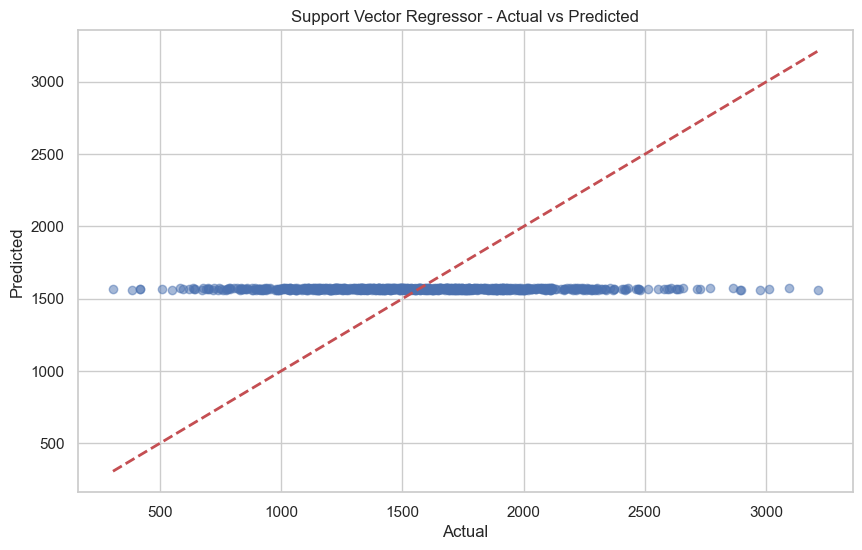

Model: GradientBoostingRegressor
Mean Squared Error: 65850.70986823658
R^2 Score: 0.6591527428368036
------------------------------


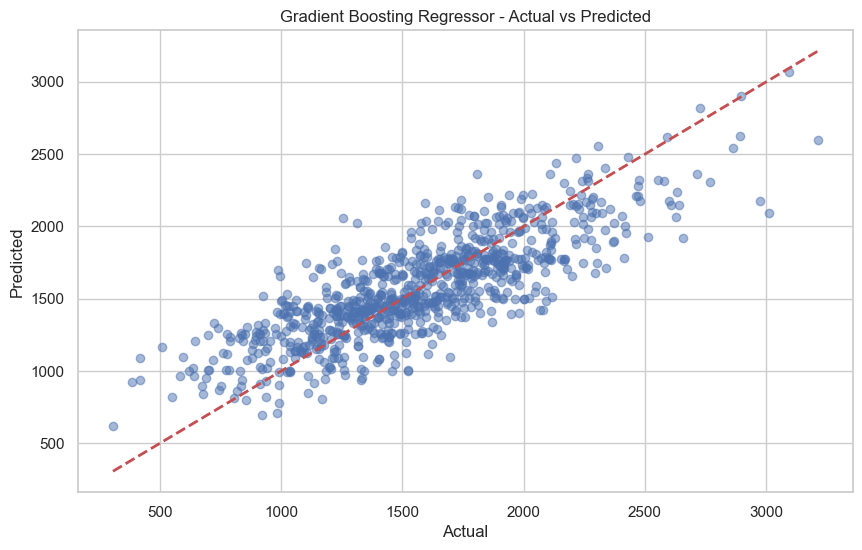

In [30]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

# Define the features and target variable
X = df.drop(columns=['total_purchase_amount'])
y = df['total_purchase_amount']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a function to evaluate the model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Model: {model.__class__.__name__}')
    print(f'Mean Squared Error: {mse}')
    print(f'R^2 Score: {r2}')
    print('-' * 30)
    return y_pred

# Define a function to plot y_pred vs y_test
def plot_predictions(y_test, y_pred, model_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{model_name} - Actual vs Predicted')
    plt.show()

# Linear Regression
lr_model =  LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = evaluate_model(lr_model, X_test, y_test)
plot_predictions(y_test, y_pred_lr, 'Linear Regression')

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = evaluate_model(rf_model, X_test, y_test)
plot_predictions(y_test, y_pred_rf, 'Random Forest Regressor')

# Support Vector Regressor
svr_model = SVR()
svr_model.fit(X_train, y_train)
y_pred_svr = evaluate_model(svr_model, X_test, y_test)
plot_predictions(y_test, y_pred_svr, 'Support Vector Regressor')

# Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)
y_pred_gbr = evaluate_model(gbr_model, X_test, y_test)
plot_predictions(y_test, y_pred_gbr, 'Gradient Boosting Regressor')

# Add more models as needed

Model: LinearRegression
Mean Squared Error: 0.13026925429837888
R^2 Score: 0.9972315244530658
------------------------------


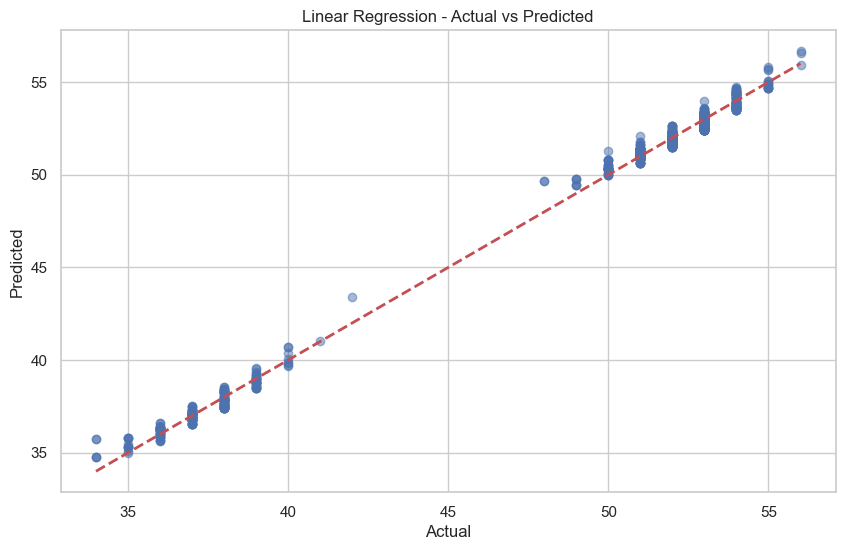

Model: RandomForestRegressor
Mean Squared Error: 0.002668721461187219
R^2 Score: 0.9999432844676461
------------------------------


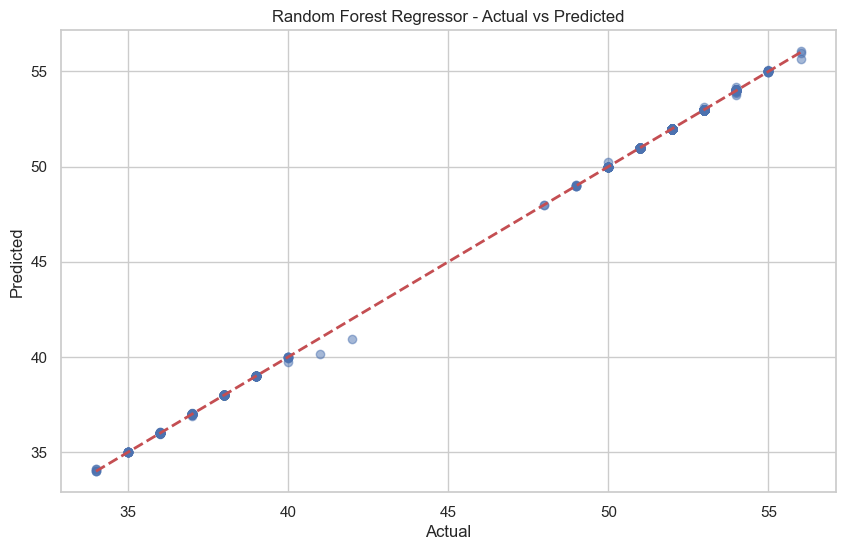

Model: SVR
Mean Squared Error: 0.4740095529716955
R^2 Score: 0.9899263731608566
------------------------------


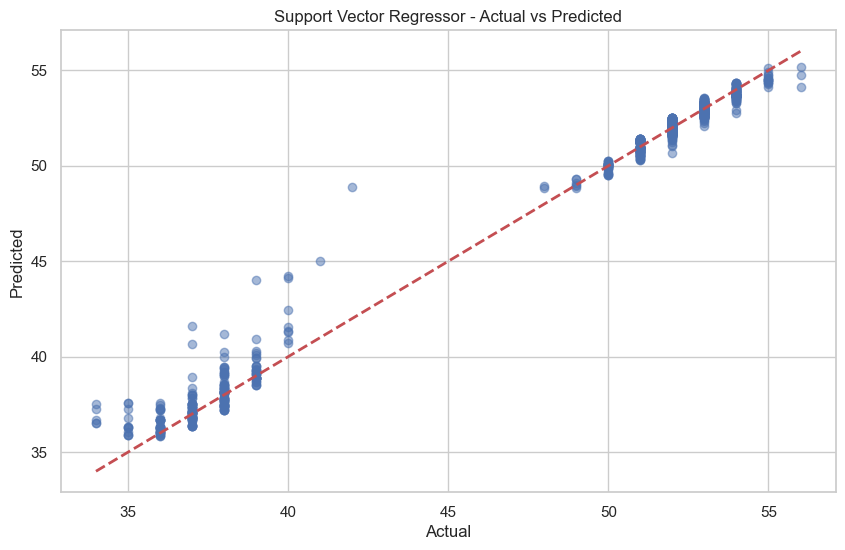

Model: GradientBoostingRegressor
Mean Squared Error: 0.04627242364715128
R^2 Score: 0.9990166208131421
------------------------------


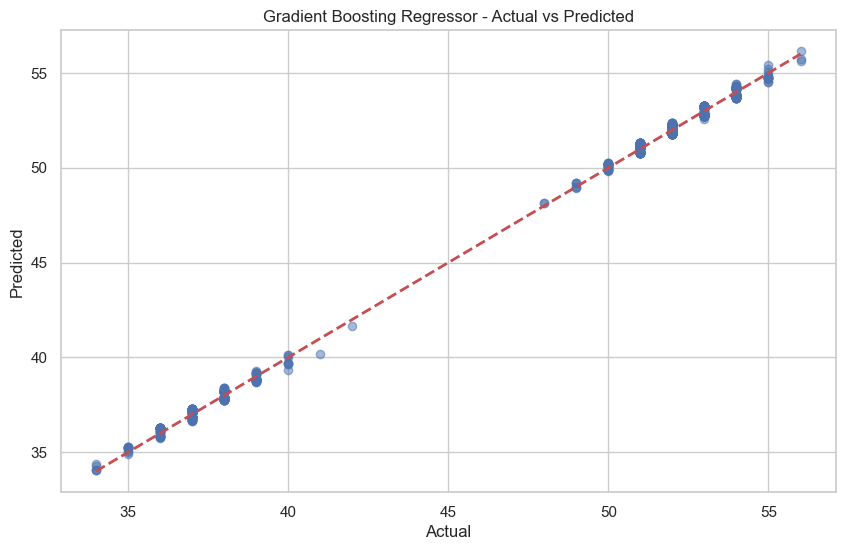

In [29]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

# Define the features and target variable
X = df.drop(columns=['time_in_store','total_purchase_amount','Cust_ID'])
y = df['time_in_store']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a function to evaluate the model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Model: {model.__class__.__name__}')
    print(f'Mean Squared Error: {mse}')
    print(f'R^2 Score: {r2}')
    print('-' * 30)
    return y_pred

# Define a function to plot y_pred vs y_test
def plot_predictions(y_test, y_pred, model_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{model_name} - Actual vs Predicted')
    plt.show()

# Linear Regression
lr_model =LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = evaluate_model(lr_model, X_test, y_test)
plot_predictions(y_test, y_pred_lr, 'Linear Regression')

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = evaluate_model(rf_model, X_test, y_test)
plot_predictions(y_test, y_pred_rf, 'Random Forest Regressor')

# Support Vector Regressor
svr_model = SVR()
svr_model.fit(X_train, y_train)
y_pred_svr = evaluate_model(svr_model, X_test, y_test)
plot_predictions(y_test, y_pred_svr, 'Support Vector Regressor')

# Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)
y_pred_gbr = evaluate_model(gbr_model, X_test, y_test)
plot_predictions(y_test, y_pred_gbr, 'Gradient Boosting Regressor')

# Add more models as needed